# Packet-Level Data Audit for Phase 2

**Project:** ECE 597 Multi-Stage IoT Intrusion Detection  
**Scope:** Packet-level data cleaning, feature review, and preprocessing decisions before Phase 2 unsupervised learning.

This notebook is intentionally focused. It answers four practical questions:

1. Are the packet files structurally consistent and clean enough to combine?
2. Which columns are model features, matching metadata, or encoding risks?
3. Which missing, skewed, constant, or redundant features need attention?
4. Which small set of preprocessing alternatives should the team test?

The notebook uses traffic labels inferred from filenames only for **descriptive comparison**.  
Those labels must not be included in the Phase 2 training feature matrix.

## Before running

Required packages:

```python
pandas
numpy
matplotlib
pyarrow
```

If an import fails, run this once in a temporary notebook cell and restart the kernel:

```python
%pip install pandas numpy matplotlib pyarrow
```

`scikit-learn` is not required for this audit notebook.

The code prefers Parquet files. If a Parquet file cannot be read and a same-name CSV exists, it automatically falls back to the CSV.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# Settings
# -----------------------------
AUDIT_ROWS_PER_FILE = 10_000
CORRELATION_SAMPLE_ROWS = 40_000
CORRELATION_THRESHOLD = 0.98
RANDOM_SEED = 42

# False means the notebook only displays results.
# Change to True only after the team decides that saved files are useful.
SAVE_RESULTS = True
EXPECTED_CLASSES = [
    "benign",
    "ddos_http",
    "dos_http",
    "dns_spoofing",
    "xss",
    "brute_force",
]

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)

print("Notebook settings loaded.")

Notebook settings loaded.


## 1. Find the local packet datasets

This section only discovers files and maps filenames to traffic classes.

Expected local folder:

```text
data/raw/packetFeatures_datasets/
```

Additional files such as `BenignTraffic1`, `BenignTraffic2`, or `DoS-HTTP_Flood1` are included automatically.  
Missing optional files do not stop the notebook.

In [2]:
def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        expected = candidate / "data" / "raw" / "packetFeatures_datasets"
        if expected.exists():
            return candidate

    # Common case: notebook is opened from the notebooks folder.
    if start.name.lower() == "notebooks":
        return start.parent

    return start


def infer_attack_type(filename: str) -> str:
    name = filename.lower().replace(" ", "_")

    if "benign" in name:
        return "benign"
    if "ddos" in name and "http" in name:
        return "ddos_http"
    if "dos" in name and "http" in name and "ddos" not in name:
        return "dos_http"
    if "dns" in name and "spoof" in name:
        return "dns_spoofing"
    if "xss" in name:
        return "xss"
    if "dictionary" in name or "bruteforce" in name or "brute_force" in name:
        return "brute_force"

    return "unknown"


def discover_packet_files(folder: Path) -> list[Path]:
    if not folder.exists():
        return []

    # Keep one source per stem. Prefer Parquet over CSV.
    chosen: dict[str, Path] = {}

    for path in sorted(folder.glob("*.csv")):
        chosen[path.stem] = path

    for path in sorted(folder.glob("*.parquet")):
        chosen[path.stem] = path

    return sorted(chosen.values(), key=lambda p: p.name.lower())


def load_table(path: Path) -> pd.DataFrame:
    """Read Parquet when possible; fall back to a same-name CSV."""
    if path.suffix.lower() == ".parquet":
        try:
            return pd.read_parquet(path)
        except Exception as exc:
            csv_path = path.with_suffix(".csv")
            if csv_path.exists():
                print(
                    f"Parquet read failed for {path.name}; "
                    f"using {csv_path.name} instead.\n"
                    f"Reason: {type(exc).__name__}: {exc}"
                )
                return pd.read_csv(csv_path, low_memory=False)
            raise RuntimeError(
                f"Could not read {path.name}, and no fallback CSV was found."
            ) from exc

    return pd.read_csv(path, low_memory=False)


REPO_ROOT = find_repo_root()
PACKET_DIR = REPO_ROOT / "data" / "raw" / "packetFeatures_datasets"
packet_files = discover_packet_files(PACKET_DIR)

print("Repository root:", REPO_ROOT)
print("Packet folder:", PACKET_DIR)
print("Packet files found:", len(packet_files))

for path in packet_files:
    print(f"  {path.name:<38} -> {infer_attack_type(path.name)}")

if not packet_files:
    raise FileNotFoundError(
        "No packet CSV or Parquet files were found. "
        "Check that the notebook is inside the repository and that "
        "data/raw/packetFeatures_datasets exists."
    )

Repository root: C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS
Packet folder: C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets
Packet files found: 10
  BenignTraffic.parquet                  -> benign
  BenignTraffic1.parquet                 -> benign
  BenignTraffic2.parquet                 -> benign
  BenignTraffic3.parquet                 -> benign
  DDoS-HTTP_Flood-.parquet               -> ddos_http
  DictionaryBruteForce.parquet           -> brute_force
  DNS_Spoofing.parquet                   -> dns_spoofing
  DoS-HTTP_Flood.parquet                 -> dos_http
  DoS-HTTP_Flood1.parquet                -> dos_http
  XSS.parquet                            -> xss


## 2. Dataset overview, schema, and basic quality

Each file is loaded one at a time. The notebook records:

- number of rows and columns;
- missing cells;
- exact duplicate rows;
- infinite numeric values;
- constant columns;
- schema consistency;
- a small sample for later feature analysis.

### How to interpret the output

- Different column sets must be resolved before concatenation.
- Duplicate rows are reported, but network packets should not be deleted automatically just because their feature values repeat.
- A constant column has no variation and is normally a strong drop candidate if it is constant across every file.
- `inf` and `-inf` must be converted to missing values before modeling.

In [3]:
inventory_rows = []
quality_rows = []
schema_records = {}
samples = []

total_missing_by_feature = pd.Series(dtype="int64")
total_rows_profiled = 0

for file_index, path in enumerate(packet_files):
    attack_type = infer_attack_type(path.name)
    print(f"Profiling {path.name} ...")

    df = load_table(path)
    rows, columns = df.shape

    schema_records[path.name] = {
        column: str(dtype)
        for column, dtype in df.dtypes.items()
    }

    missing_by_feature = df.isna().sum()
    total_missing_by_feature = total_missing_by_feature.add(
        missing_by_feature, fill_value=0
    )
    total_rows_profiled += rows

    numeric_df = df.select_dtypes(include=[np.number])
    infinite_count = (
        int(np.isinf(numeric_df.to_numpy(dtype="float64", na_value=np.nan)).sum())
        if not numeric_df.empty
        else 0
    )

    duplicate_rows = int(df.duplicated().sum())
    constant_columns = [
        column
        for column in df.columns
        if df[column].nunique(dropna=False) <= 1
    ]

    inventory_rows.append(
        {
            "source_file": path.name,
            "attack_type": attack_type,
            "rows": rows,
            "columns": columns,
            "file_size_mb": round(path.stat().st_size / 1024**2, 2),
        }
    )

    quality_rows.append(
        {
            "source_file": path.name,
            "attack_type": attack_type,
            "missing_cells": int(missing_by_feature.sum()),
            "missing_cell_pct": float(missing_by_feature.sum() / (rows * columns) * 100),
            "columns_with_missing": int((missing_by_feature > 0).sum()),
            "duplicate_rows": duplicate_rows,
            "duplicate_row_pct": float(duplicate_rows / max(rows, 1) * 100),
            "infinite_values": infinite_count,
            "constant_column_count": len(constant_columns),
            "constant_columns": constant_columns,
        }
    )

    sample_n = min(AUDIT_ROWS_PER_FILE, rows)
    sample = df.sample(
        n=sample_n,
        random_state=RANDOM_SEED + file_index,
    ).copy()
    sample["attack_type"] = attack_type
    sample["source_file"] = path.name
    samples.append(sample)

    del df, numeric_df, sample

inventory = pd.DataFrame(inventory_rows)
quality_summary = pd.DataFrame(quality_rows)
audit_df = pd.concat(samples, ignore_index=True)

display(inventory.sort_values(["attack_type", "source_file"]))
display(
    quality_summary[
        [
            "source_file",
            "attack_type",
            "missing_cell_pct",
            "columns_with_missing",
            "duplicate_rows",
            "infinite_values",
            "constant_column_count",
        ]
    ].sort_values(["attack_type", "source_file"])
)

print(f"\nTotal packet rows found: {inventory['rows'].sum():,}")
print(f"Audit sample rows: {len(audit_df):,}")

Profiling BenignTraffic.parquet ...
Profiling BenignTraffic1.parquet ...
Profiling BenignTraffic2.parquet ...
Profiling BenignTraffic3.parquet ...
Profiling DDoS-HTTP_Flood-.parquet ...
Profiling DictionaryBruteForce.parquet ...
Profiling DNS_Spoofing.parquet ...
Profiling DoS-HTTP_Flood.parquet ...
Profiling DoS-HTTP_Flood1.parquet ...
Profiling XSS.parquet ...


,source_file,attack_type,rows,columns,file_size_mb
0,BenignTraffic.parquet,benign,297063,135,101.55
1,BenignTraffic1.parquet,benign,295201,135,123.84
2,BenignTraffic2.parquet,benign,295200,135,122.14
3,BenignTraffic3.parquet,benign,295334,135,122.06
5,DictionaryBruteForce.parquet,brute_force,131477,135,53.84
4,DDoS-HTTP_Flood-.parquet,ddos_http,290346,135,139.93
6,DNS_Spoofing.parquet,dns_spoofing,296025,135,125.45
7,DoS-HTTP_Flood.parquet,dos_http,156328,135,84.57
8,DoS-HTTP_Flood1.parquet,dos_http,157711,135,82.79
9,XSS.parquet,xss,40101,135,14.73


,source_file,attack_type,missing_cell_pct,columns_with_missing,duplicate_rows,infinite_values,constant_column_count
0,BenignTraffic.parquet,benign,4.196870,49,0,0,2
1,BenignTraffic1.parquet,benign,2.301970,49,0,0,2
2,BenignTraffic2.parquet,benign,2.355912,49,0,0,2
3,BenignTraffic3.parquet,benign,2.312668,49,0,0,2
5,DictionaryBruteForce.parquet,brute_force,3.581908,49,0,0,2
4,DDoS-HTTP_Flood-.parquet,ddos_http,2.863896,49,0,0,2
6,DNS_Spoofing.parquet,dns_spoofing,3.358210,49,0,0,2
7,DoS-HTTP_Flood.parquet,dos_http,2.369733,49,0,0,2
8,DoS-HTTP_Flood1.parquet,dos_http,2.792872,49,0,0,2
9,XSS.parquet,xss,5.210455,49,0,0,2



Total packet rows found: 2,254,786
Audit sample rows: 100,000


In [4]:
# Schema consistency summary
reference_file = inventory.iloc[0]["source_file"]
reference_schema = schema_records[reference_file]
reference_columns = list(reference_schema)

schema_rows = []
for file_name, schema in schema_records.items():
    columns = list(schema)
    missing_columns = sorted(set(reference_columns) - set(columns))
    extra_columns = sorted(set(columns) - set(reference_columns))
    type_mismatches = [
        column
        for column in set(reference_columns).intersection(columns)
        if reference_schema[column] != schema[column]
    ]

    schema_rows.append(
        {
            "source_file": file_name,
            "same_column_order": columns == reference_columns,
            "missing_column_count": len(missing_columns),
            "extra_column_count": len(extra_columns),
            "type_mismatch_count": len(type_mismatches),
            "missing_columns": missing_columns,
            "extra_columns": extra_columns,
            "type_mismatches": type_mismatches,
        }
    )

schema_summary = pd.DataFrame(schema_rows)
display(
    schema_summary[
        [
            "source_file",
            "same_column_order",
            "missing_column_count",
            "extra_column_count",
            "type_mismatch_count",
        ]
    ]
)

schema_ok = (
    schema_summary["same_column_order"].all()
    and (schema_summary["missing_column_count"] == 0).all()
    and (schema_summary["extra_column_count"] == 0).all()
    and (schema_summary["type_mismatch_count"] == 0).all()
)

print("Schema ready for combination:", schema_ok)

,source_file,same_column_order,missing_column_count,extra_column_count,type_mismatch_count
0,BenignTraffic.parquet,True,0,0,0
1,BenignTraffic1.parquet,True,0,0,0
2,BenignTraffic2.parquet,True,0,0,0
3,BenignTraffic3.parquet,True,0,0,0
4,DDoS-HTTP_Flood-.parquet,True,0,0,0
5,DictionaryBruteForce.parquet,True,0,0,0
6,DNS_Spoofing.parquet,True,0,0,0
7,DoS-HTTP_Flood.parquet,True,0,0,0
8,DoS-HTTP_Flood1.parquet,True,0,0,0
9,XSS.parquet,True,0,0,0


Schema ready for combination: True


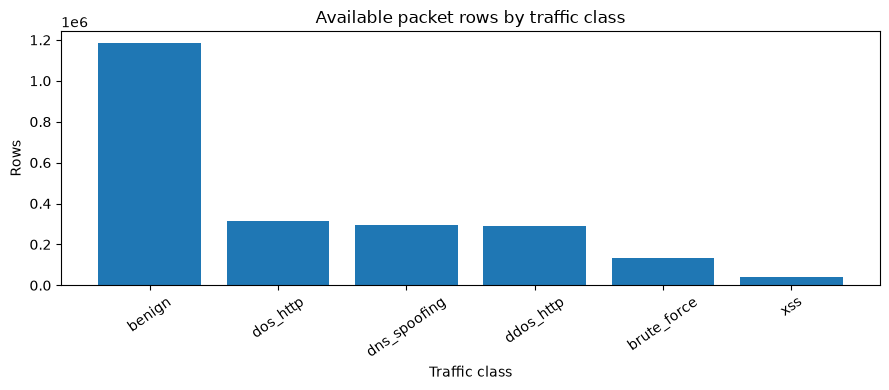

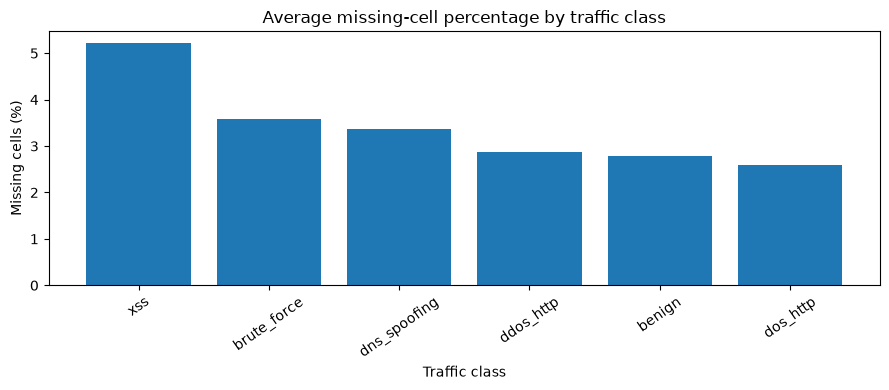

In [5]:
# Two compact overview charts
class_rows = (
    inventory.groupby("attack_type", as_index=False)["rows"]
    .sum()
    .sort_values("rows", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_rows["attack_type"], class_rows["rows"])
ax.set_title("Available packet rows by traffic class")
ax.set_xlabel("Traffic class")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

quality_by_class = (
    quality_summary.groupby("attack_type", as_index=False)["missing_cell_pct"]
    .mean()
    .sort_values("missing_cell_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(quality_by_class["attack_type"], quality_by_class["missing_cell_pct"])
ax.set_title("Average missing-cell percentage by traffic class")
ax.set_xlabel("Traffic class")
ax.set_ylabel("Missing cells (%)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 3. Feature roles and feature-level audit

The columns are divided into practical roles:

- **matching metadata** — needed later to connect packet alerts to flows, but excluded from the default model input;
- **port review** — ports may carry service information, but raw port numbers should not be treated as ordinary continuous measurements without discussion;
- **categorical review** — may need encoding or exclusion;
- **numeric candidate** — possible Phase 2 input after cleaning and scaling.

The automatic recommendation is only a starting point. It is not the final team decision.

In [6]:
MATCHING_COLUMNS = {
    "stream",
    "src_ip",
    "dst_ip",
    "src_mac",
    "dst_mac",
    "device_mac",
}

PORT_COLUMNS = {"src_port", "dst_port"}


def classify_role(column: str, dtype) -> str:
    if column in MATCHING_COLUMNS:
        return "matching_metadata"
    if column in PORT_COLUMNS:
        return "port_review"
    if pd.api.types.is_numeric_dtype(dtype):
        return "numeric_candidate"
    return "categorical_review"


# Columns constant in every profiled file
constant_sets = [
    set(columns)
    for columns in quality_summary["constant_columns"]
]
globally_constant = (
    set.intersection(*constant_sets)
    if constant_sets
    else set()
)

feature_rows = []

for column in reference_columns:
    series = audit_df[column]
    role = classify_role(column, series.dtype)

    missing_count = int(total_missing_by_feature.get(column, 0))
    missing_pct = missing_count / max(total_rows_profiled, 1) * 100

    non_missing = series.dropna()
    unique_count = int(non_missing.nunique())
    dominant_pct = (
        float(non_missing.value_counts(normalize=True, dropna=False).iloc[0] * 100)
        if len(non_missing)
        else np.nan
    )

    if pd.api.types.is_numeric_dtype(series):
        numeric = pd.to_numeric(series, errors="coerce").replace(
            [np.inf, -np.inf], np.nan
        )
        zero_pct = float((numeric == 0).mean() * 100)
        skewness = float(numeric.skew()) if numeric.notna().sum() > 2 else np.nan
    else:
        zero_pct = np.nan
        skewness = np.nan

    if role == "matching_metadata":
        action = "metadata_only"
        reason = "Keep for matching/grouping; exclude from the default Phase 2 matrix."
    elif column in globally_constant:
        action = "drop_candidate"
        reason = "Constant across all currently profiled packet files."
    elif role == "port_review":
        action = "review_or_transform"
        reason = "Potential service signal, but raw port numbers are identity-like."
    elif role == "categorical_review" and unique_count <= 10:
        action = "encode_candidate"
        reason = "Low-cardinality categorical feature; explicit encoding is possible."
    elif role == "categorical_review":
        action = "exclude_or_special_encode"
        reason = "High-cardinality categorical feature; direct one-hot encoding may be unsuitable."
    elif missing_pct >= 80:
        action = "review_structural_missing"
        reason = "Very high missingness; determine whether the field is protocol-specific."
    elif pd.notna(skewness) and abs(skewness) >= 5:
        action = "transform_candidate"
        reason = "Strong numeric skew; compare robust scaling with log transformation."
    else:
        action = "keep_candidate"
        reason = "No immediate exclusion rule was triggered."

    feature_rows.append(
        {
            "feature": column,
            "dtype": str(series.dtype),
            "role": role,
            "missing_pct": missing_pct,
            "unique_count_in_audit_sample": unique_count,
            "dominant_value_pct": dominant_pct,
            "zero_pct": zero_pct,
            "skewness": skewness,
            "initial_action": action,
            "reason": reason,
        }
    )

feature_audit = pd.DataFrame(feature_rows)

role_counts = feature_audit["role"].value_counts()
action_counts = feature_audit["initial_action"].value_counts()

display(role_counts.rename("feature_count").to_frame())
display(action_counts.rename("feature_count").to_frame())

print("Globally constant columns:", sorted(globally_constant))

,feature_count
role,
numeric_candidate,116
categorical_review,11
matching_metadata,6
port_review,2


,feature_count
initial_action,
keep_candidate,78
transform_candidate,36
exclude_or_special_encode,7
metadata_only,6
encode_candidate,3
review_or_transform,2
drop_candidate,2
review_structural_missing,1


Globally constant columns: ['handshake_ciphersuites', 'http_host']


## 4. Missing values and protocol-specific fields

A high missing percentage does not automatically mean that a column is bad.

For example:

- DNS fields may be unavailable for non-DNS packets;
- HTTP fields may be unavailable outside HTTP traffic;
- rolling variance fields may be missing when a window has too few observations.

The useful question is whether missingness is:

1. a data extraction problem;
2. a meaningful “not applicable” state;
3. or a reason to remove the feature.

,feature,role,missing_pct,initial_action,reason
27,dns_query_type,numeric_candidate,96.699022,review_structural_missing,Very high missingness; determine whether the f...
57,stream_jitter_1_var,numeric_candidate,23.214753,transform_candidate,Strong numeric skew; compare robust scaling wi...
45,stream_1_var,numeric_candidate,21.096104,keep_candidate,No immediate exclusion rule was triggered.
48,src_ip_1_var,numeric_candidate,16.861778,transform_candidate,Strong numeric skew; compare robust scaling wi...
51,src_ip_mac_1_var,numeric_candidate,16.043962,transform_candidate,Strong numeric skew; compare robust scaling wi...
72,stream_jitter_5_var,numeric_candidate,14.449531,transform_candidate,Strong numeric skew; compare robust scaling wi...
60,stream_5_var,numeric_candidate,11.454125,keep_candidate,No immediate exclusion rule was triggered.
54,channel_1_var,numeric_candidate,10.906800,keep_candidate,No immediate exclusion rule was triggered.
87,stream_jitter_10_var,numeric_candidate,10.837614,transform_candidate,Strong numeric skew; compare robust scaling wi...
63,src_ip_5_var,numeric_candidate,10.595994,keep_candidate,No immediate exclusion rule was triggered.


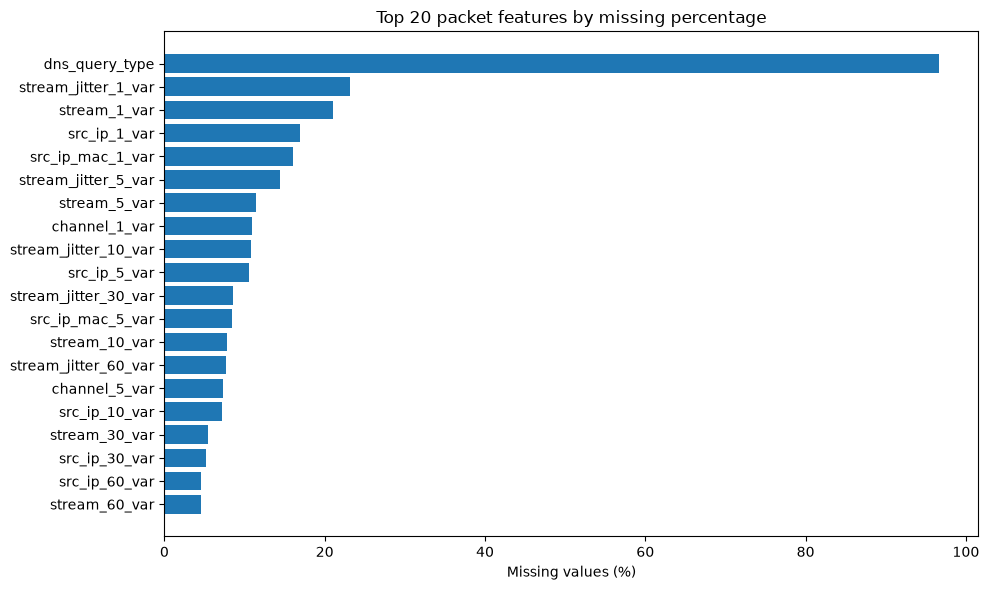

In [7]:
# Top missing features across all full files
top_missing = (
    feature_audit.sort_values("missing_pct", ascending=False)
    .head(20)[
        [
            "feature",
            "role",
            "missing_pct",
            "initial_action",
            "reason",
        ]
    ]
)

display(top_missing)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top_missing.sort_values("missing_pct")
ax.barh(plot_data["feature"], plot_data["missing_pct"])
ax.set_title("Top 20 packet features by missing percentage")
ax.set_xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

attack_type,benign,brute_force,ddos_http,dns_spoofing,dos_http,xss
dns_query_type,95.11,97.74,99.29,97.16,99.10,94.31
stream_jitter_1_var,15.95,21.87,45.48,17.74,35.22,31.54
stream_1_var,13.53,19.79,44.03,15.54,33.25,27.81
src_ip_1_var,19.59,28.13,2.55,26.11,3.92,46.01
src_ip_mac_1_var,18.90,27.15,2.14,23.96,3.57,43.14
stream_jitter_5_var,11.66,14.12,22.92,13.04,18.57,21.50
stream_5_var,9.20,11.98,16.63,10.79,14.70,17.66
channel_1_var,12.97,17.16,1.59,14.86,2.48,28.27
stream_jitter_10_var,8.60,9.94,18.18,9.17,14.25,15.41
src_ip_5_var,12.67,17.60,1.47,15.89,2.08,27.77


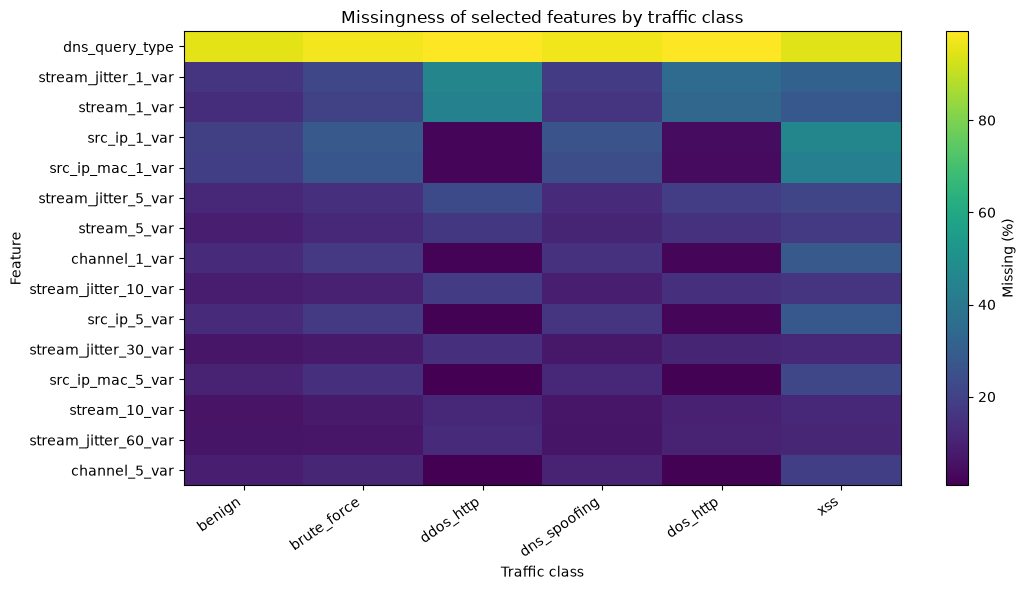

In [8]:
# Missingness by traffic class, based on the balanced audit sample
missing_by_class = (
    audit_df.groupby("attack_type")[reference_columns]
    .apply(lambda frame: frame.isna().mean() * 100)
)

focus_missing_features = top_missing["feature"].head(15).tolist()
missing_view = missing_by_class[focus_missing_features].T

display(missing_view.round(2))

fig, ax = plt.subplots(figsize=(11, 6))
image = ax.imshow(missing_view.to_numpy(), aspect="auto")
ax.set_title("Missingness of selected features by traffic class")
ax.set_xlabel("Traffic class")
ax.set_ylabel("Feature")
ax.set_xticks(range(len(missing_view.columns)))
ax.set_xticklabels(missing_view.columns, rotation=35, ha="right")
ax.set_yticks(range(len(missing_view.index)))
ax.set_yticklabels(missing_view.index)
fig.colorbar(image, ax=ax, label="Missing (%)")
plt.tight_layout()
plt.show()

## 5. Categorical and numeric preprocessing risks

This section focuses on decisions that affect Phase 2:

- high-cardinality categorical values can create huge one-hot matrices or memorize the environment;
- strongly skewed numeric values can dominate distance-based models;
- zero-heavy and sentinel-heavy fields may need special treatment;
- identifiers should remain available separately for matching and evaluation.

In [9]:
categorical_profile = (
    feature_audit[feature_audit["role"] == "categorical_review"]
    [
        [
            "feature",
            "missing_pct",
            "unique_count_in_audit_sample",
            "dominant_value_pct",
            "initial_action",
        ]
    ]
    .sort_values(
        ["unique_count_in_audit_sample", "missing_pct"],
        ascending=[False, False],
    )
)

display(categorical_profile)

print(
    "\nInterpretation: low-cardinality fields can be tested with explicit "
    "encoding; high-cardinality identity or text fields should usually be "
    "excluded from the first numeric baseline."
)

,feature,missing_pct,unique_count_in_audit_sample,dominant_value_pct,initial_action
36,http_uri,0.0,9111,90.564,exclude_or_special_encode
25,user_agent,0.0,754,91.363,exclude_or_special_encode
26,dns_server,0.0,169,96.715,exclude_or_special_encode
20,tls_server,0.0,48,99.806,exclude_or_special_encode
33,eth_dst_oui,0.0,39,29.747,exclude_or_special_encode
32,eth_src_oui,0.0,37,27.236,exclude_or_special_encode
35,highest_layer,0.0,34,53.185,exclude_or_special_encode
38,http_content_type,0.0,8,96.934,encode_candidate
22,http_request_method,0.0,5,91.399,encode_candidate
16,handshake_version,0.0,3,99.621,encode_candidate



Interpretation: low-cardinality fields can be tested with explicit encoding; high-cardinality identity or text fields should usually be excluded from the first numeric baseline.


,feature,missing_pct,zero_pct,skewness,initial_action,absolute_skewness
8,time_since_previously_displayed_frame,0.000000,5.475,292.922149,transform_candidate,292.922149
42,jitter,3.324484,0.000,212.712198,transform_candidate,212.712198
118,ntp_interval,0.000000,99.739,148.553296,transform_candidate,148.553296
29,dns_interval,0.000000,96.739,124.120965,transform_candidate,124.120965
56,stream_jitter_1_mean,3.324484,0.000,117.896034,transform_candidate,117.896034
71,stream_jitter_5_mean,3.324484,0.000,111.310200,transform_candidate,111.310200
86,stream_jitter_10_mean,3.324484,0.000,110.755562,transform_candidate,110.755562
101,stream_jitter_30_mean,3.324484,0.000,108.376421,transform_candidate,108.376421
116,stream_jitter_60_mean,3.324484,0.000,101.355707,transform_candidate,101.355707
57,stream_jitter_1_var,23.214753,0.001,90.445104,transform_candidate,90.445104


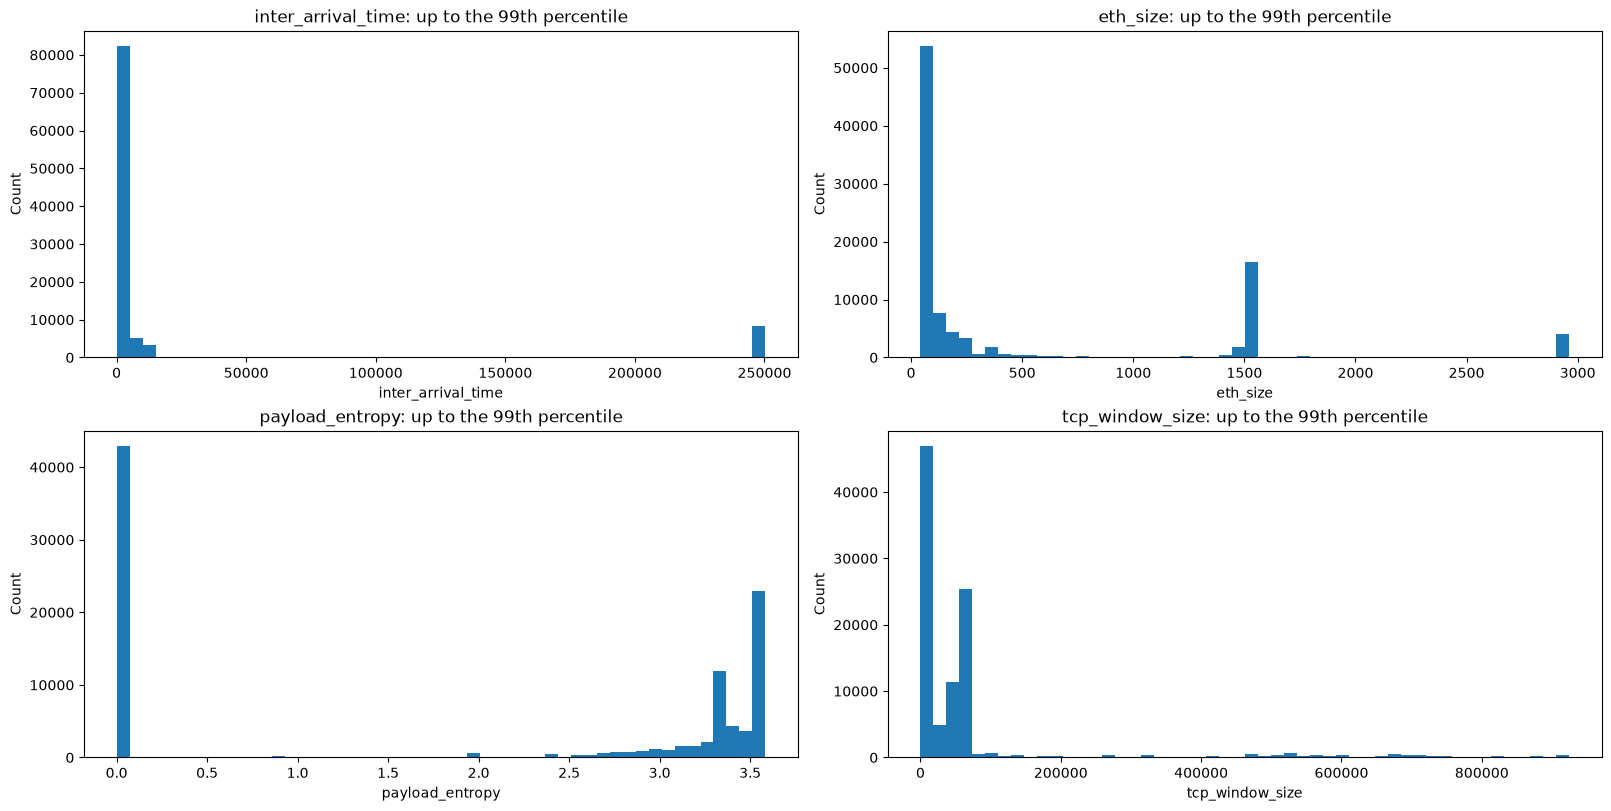

In [10]:
numeric_diagnostics = (
    feature_audit[feature_audit["role"] == "numeric_candidate"]
    [
        [
            "feature",
            "missing_pct",
            "zero_pct",
            "skewness",
            "initial_action",
        ]
    ]
    .copy()
)

numeric_diagnostics["absolute_skewness"] = numeric_diagnostics["skewness"].abs()

display(
    numeric_diagnostics.sort_values(
        "absolute_skewness", ascending=False
    ).head(20)
)

# Plot up to four representative numeric features in a compact 2 × 2 layout.
# Each panel keeps approximately the same 8 × 4 size as the previous
# one-chart-per-output version, so the full figure is 16 × 8.
preferred = [
    "inter_arrival_time",
    "eth_size",
    "payload_entropy",
    "tcp_window_size",
]

plot_features = [
    feature
    for feature in preferred
    if feature in audit_df.columns
    and pd.api.types.is_numeric_dtype(audit_df[feature])
][:4]

if plot_features:
    rows = 2
    columns = 2

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, 8),
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(-1)

    for axis, feature in zip(axes, plot_features):
        values = pd.to_numeric(
            audit_df[feature],
            errors="coerce",
        ).replace([np.inf, -np.inf], np.nan).dropna()

        if values.empty:
            axis.set_visible(False)
            continue

        upper = values.quantile(0.99)
        clipped = values[values <= upper]

        axis.hist(clipped, bins=50)
        axis.set_title(f"{feature}: up to the 99th percentile")
        axis.set_xlabel(feature)
        axis.set_ylabel("Count")

    # Hide unused panels when fewer than four preferred features exist.
    for axis in axes[len(plot_features):]:
        axis.set_visible(False)

    plt.show()
else:
    print("None of the preferred representative numeric features were found.")

## 6. Redundancy and high correlation

Highly correlated features can repeatedly represent the same behaviour and unintentionally give it extra weight in K-means, PCA, autoencoders, or other distance-sensitive methods.

However, correlation alone is not a sufficient reason to drop a feature.  
Different rolling windows may be correlated while still representing different time scales.

This section identifies pairs for team review; it does not delete them automatically.

In [11]:
numeric_candidates = feature_audit.loc[
    feature_audit["role"] == "numeric_candidate",
    "feature",
].tolist()

corr_data = audit_df[numeric_candidates].replace(
    [np.inf, -np.inf], np.nan
)

if len(corr_data) > CORRELATION_SAMPLE_ROWS:
    corr_data = corr_data.sample(
        CORRELATION_SAMPLE_ROWS,
        random_state=RANDOM_SEED,
    )

# Exclude columns with no useful variation in the audit sample.
usable_corr_columns = [
    column
    for column in corr_data.columns
    if corr_data[column].nunique(dropna=True) > 1
]

corr_matrix = corr_data[usable_corr_columns].corr(method="spearman")

correlation_pairs = []
for i, left in enumerate(corr_matrix.columns):
    for right in corr_matrix.columns[i + 1:]:
        value = corr_matrix.loc[left, right]
        if pd.notna(value) and abs(value) >= CORRELATION_THRESHOLD:
            correlation_pairs.append(
                {
                    "feature_1": left,
                    "feature_2": right,
                    "spearman_correlation": float(value),
                    "absolute_correlation": float(abs(value)),
                }
            )

high_correlation_pairs = pd.DataFrame(correlation_pairs)

if high_correlation_pairs.empty:
    print("No feature pairs met the correlation threshold.")
else:
    high_correlation_pairs = high_correlation_pairs.sort_values(
        "absolute_correlation",
        ascending=False,
    )
    print(
        f"Pairs with |Spearman correlation| >= "
        f"{CORRELATION_THRESHOLD}: {len(high_correlation_pairs)}"
    )
    display(high_correlation_pairs.head(15))

Pairs with |Spearman correlation| >= 0.98: 50


,feature_1,feature_2,spearman_correlation,absolute_correlation
47,q1,q1_e,1.000000,1.000000
46,min_et,min_e,1.000000,1.000000
49,sum_p,average_p,1.000000,1.000000
0,handshake_cipher_suites_length,handshake_extensions_length,0.999994,0.999994
3,icmp_type,icmp_checksum_status,0.999976,0.999976
22,src_ip_10_count,src_ip_mac_10_count,0.999740,0.999740
29,src_ip_30_count,src_ip_mac_30_count,0.999717,0.999717
8,src_ip_5_count,src_ip_mac_5_count,0.999716,0.999716
43,src_ip_60_count,src_ip_mac_60_count,0.999703,0.999703
4,src_ip_1_count,src_ip_mac_1_count,0.999601,0.999601


## 7. Descriptive comparison across traffic classes

This is a small **interpretation-only** analysis.

It compares each attack class with benign traffic using the difference in median values, normalized by the benign interquartile range.

Use this section to understand behaviour and select useful plots for the report.  
Do **not** use it as the only rule for selecting Phase 2 features, because Phase 2 training must remain unsupervised.

In [12]:
comparison_features = [
    feature
    for feature in numeric_candidates
    if feature not in globally_constant
]

benign_data = audit_df[audit_df["attack_type"] == "benign"]

comparison_rows = []

if benign_data.empty:
    print("No benign file was found, so attack-to-benign comparison was skipped.")
else:
    benign_median = benign_data[comparison_features].median(numeric_only=True)
    benign_q1 = benign_data[comparison_features].quantile(0.25, numeric_only=True)
    benign_q3 = benign_data[comparison_features].quantile(0.75, numeric_only=True)
    benign_iqr = (benign_q3 - benign_q1).replace(0, np.nan)

    for attack_type in EXPECTED_CLASSES:
        if attack_type == "benign":
            continue

        attack_data = audit_df[audit_df["attack_type"] == attack_type]
        if attack_data.empty:
            continue

        attack_median = attack_data[comparison_features].median(numeric_only=True)
        score = ((attack_median - benign_median).abs() / benign_iqr).replace(
            [np.inf, -np.inf], np.nan
        )

        for feature, value in score.dropna().items():
            comparison_rows.append(
                {
                    "attack_type": attack_type,
                    "feature": feature,
                    "normalized_median_shift": float(value),
                }
            )

class_comparison = pd.DataFrame(comparison_rows)

if not class_comparison.empty:
    top_by_attack = (
        class_comparison.sort_values(
            ["attack_type", "normalized_median_shift"],
            ascending=[True, False],
        )
        .groupby("attack_type")
        .head(5)
    )
    display(top_by_attack)

,attack_type,feature,normalized_median_shift
388,brute_force,inter_arrival_time,155.249882
411,brute_force,stream_jitter_1_var,1.850578
409,brute_force,stream_jitter_1_sum,0.871958
473,brute_force,min_et,0.666667
474,brute_force,min_e,0.666667
78,ddos_http,channel_60_count,7.256872
12,ddos_http,src_ip_1_count,7.034483
15,ddos_http,src_ip_mac_1_count,6.965517
75,ddos_http,src_ip_mac_60_count,6.635066
57,ddos_http,src_ip_30_count,6.470963


## 8. Candidate feature sets for the first Phase 2 experiments

Instead of agreeing on one irreversible feature list now, compare a few defensible alternatives using the same split and the same model.

### Set A — Minimal numeric baseline
- numeric behavioural features;
- exclude matching metadata;
- remove globally constant columns;
- handle missing and infinite values;
- robust scaling.

### Set B — Reduced numeric baseline
- start from Set A;
- temporarily remove extremely high-missing features;
- review highly correlated families rather than deleting every correlated field automatically.

### Set C — Small categorical expansion
- start from Set B;
- add only low-cardinality categorical features;
- keep high-cardinality identity/text fields out of the first baseline.

In [13]:
set_a_numeric = [
    feature
    for feature in numeric_candidates
    if feature not in globally_constant
]

set_b_numeric = feature_audit.loc[
    (feature_audit["feature"].isin(set_a_numeric))
    & (feature_audit["missing_pct"] < 80)
    & (feature_audit["dominant_value_pct"].fillna(0) < 99.9),
    "feature",
].tolist()

set_c_categorical = feature_audit.loc[
    (feature_audit["role"] == "categorical_review")
    & (feature_audit["unique_count_in_audit_sample"] >= 2)
    & (feature_audit["unique_count_in_audit_sample"] <= 10),
    "feature",
].tolist()

candidate_feature_sets = {
    "set_a_minimal_numeric": set_a_numeric,
    "set_b_reduced_numeric": set_b_numeric,
    "set_c_low_cardinality_categorical_additions": set_c_categorical,
}

summary = pd.DataFrame(
    [
        {
            "feature_set": "Set A: minimal numeric",
            "feature_count": len(set_a_numeric),
            "purpose": "Safe first numeric baseline.",
        },
        {
            "feature_set": "Set B: reduced numeric",
            "feature_count": len(set_b_numeric),
            "purpose": "Test whether removing extreme missing/near-constant fields helps.",
        },
        {
            "feature_set": "Set C additions",
            "feature_count": len(set_c_categorical),
            "purpose": "Low-cardinality categorical fields to test separately.",
        },
    ]
)

display(summary)

print("\nSet C categorical additions:")
print(set_c_categorical)

,feature_set,feature_count,purpose
0,Set A: minimal numeric,115,Safe first numeric baseline.
1,Set B: reduced numeric,114,Test whether removing extreme missing/near-con...
2,Set C additions,3,Low-cardinality categorical fields to test sep...



Set C categorical additions:
['handshake_version', 'http_request_method', 'http_content_type']


## 9. Proposed team decisions

A reasonable first proposal is:

| Issue | Initial proposal |
|---|---|
| IP, MAC, stream identifiers | Keep separately for matching and grouped splitting; exclude from the default Phase 2 matrix |
| Globally constant fields | Drop after confirming they are constant in the full local dataset |
| Missing DNS/HTTP/TLS fields | Treat as potentially structural; consider explicit missing indicators rather than immediate deletion |
| `inf` / `-inf` | Replace with missing values before imputation |
| Strongly skewed numeric fields | Compare robust scaling with `log1p` plus robust scaling |
| High-correlation families | Review by feature family and compare reduced vs unreduced baselines |
| High-cardinality categorical fields | Exclude from the first baseline or test a special encoding later |
| Low-cardinality categorical fields | Test separately as an expanded feature set |
| Outliers | Do not remove automatically because attacks may appear as extreme traffic |

### Recommended preprocessing order

1. Keep matching metadata in a separate table.
2. Split data before fitting any imputer or scaler.
3. Replace infinite values with missing values.
4. Fit missing-value handling on the training data only.
5. Fit scaling or transformations on the training data only.
6. Train Phase 2 without using attack labels.
7. Use labels only for evaluation and interpretation.

In [14]:
team_review = feature_audit[
    [
        "feature",
        "role",
        "missing_pct",
        "unique_count_in_audit_sample",
        "dominant_value_pct",
        "skewness",
        "initial_action",
        "reason",
    ]
].copy()

# Show only the rows most likely to need discussion.
priority_actions = {
    "metadata_only",
    "drop_candidate",
    "review_or_transform",
    "review_structural_missing",
    "exclude_or_special_encode",
    "transform_candidate",
}

priority_review = team_review[
    team_review["initial_action"].isin(priority_actions)
].sort_values(
    ["initial_action", "missing_pct"],
    ascending=[True, False],
)

display(priority_review.head(40))

print(
    "\nThe full feature_audit DataFrame remains available in memory. "
    "The notebook intentionally displays only the main discussion candidates."
)

,feature,role,missing_pct,unique_count_in_audit_sample,dominant_value_pct,skewness,initial_action,reason
18,handshake_ciphersuites,numeric_candidate,0.000000,1,100.000000,0.000000,drop_candidate,Constant across all currently profiled packet ...
23,http_host,categorical_review,0.000000,1,100.000000,NaN,drop_candidate,Constant across all currently profiled packet ...
20,tls_server,categorical_review,0.000000,48,99.806000,NaN,exclude_or_special_encode,High-cardinality categorical feature; direct o...
25,user_agent,categorical_review,0.000000,754,91.363000,NaN,exclude_or_special_encode,High-cardinality categorical feature; direct o...
26,dns_server,categorical_review,0.000000,169,96.715000,NaN,exclude_or_special_encode,High-cardinality categorical feature; direct o...
...,...,...,...,...,...,...,...,...
116,stream_jitter_60_mean,numeric_candidate,3.324484,96318,0.047672,101.355707,transform_candidate,Strong numeric skew; compare robust scaling wi...
8,time_since_previously_displayed_frame,numeric_candidate,0.000000,29072,9.915000,292.922149,transform_candidate,Strong numeric skew; compare robust scaling wi...
17,handshake_cipher_suites_length,numeric_candidate,0.000000,26,99.621000,21.376541,transform_candidate,Strong numeric skew; compare robust scaling wi...
19,handshake_extensions_length,numeric_candidate,0.000000,38,99.621000,26.466361,transform_candidate,Strong numeric skew; compare robust scaling wi...



The full feature_audit DataFrame remains available in memory. The notebook intentionally displays only the main discussion candidates.


## 10. Optional saving

Saving is disabled by default.

The notebook output is enough for the meeting. After the team makes real decisions, it may be useful to save only:

- the feature review table;
- the agreed candidate feature sets.

This avoids filling `results/` with temporary files that no later code uses.

In [15]:
if SAVE_RESULTS:
    output_dir = REPO_ROOT / "results" / "feature_audit"
    output_dir.mkdir(parents=True, exist_ok=True)

    feature_audit.to_csv(
        output_dir / "packet_feature_audit_summary.csv",
        index=False,
    )

    with open(
        output_dir / "candidate_feature_sets.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(candidate_feature_sets, file, indent=2)

    print("Saved results to:", output_dir)
else:
    print(
        "SAVE_RESULTS is False. Nothing was written to the results folder."
    )

Saved results to: C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\results\feature_audit


## 11. Final Phase 2 Top-10 feature selection

This section produces one deterministic **Phase 2 packet-level anomaly-detection Top 10**.

The selection is designed to prevent the main problems found in the earlier shortlist:

- repeated time-window versions of the same measurement;
- highly correlated features receiving duplicate weight;
- one attack type dominating the list;
- sparse, constant, identifier, or near-constant fields entering the model;
- very large raw effect sizes overwhelming the ranking.

The final method uses:

1. **Set B eligibility** from Section 8;
2. a stricter compact-list quality filter;
3. rank-based relevance within each of the five attack types;
4. explicit coverage of all five attacks;
5. a maximum absolute Spearman correlation of `0.80`;
6. one representative per repeated semantic feature family;
7. automatic training-readiness checks.

Labels are used only to rank candidate features during EDA. They must not be included in the unsupervised training matrix.

In [16]:
import re
from collections import Counter

# -----------------------------
# Final compact-selection rules
# -----------------------------
FINAL_FEATURE_COUNT = 10
ATTACK_SUPPORT_PERCENTILE = 0.80
MAX_COMPACT_MISSING_PCT = 25.0
MAX_COMPACT_DOMINANT_PCT = 99.5
MAX_SELECTED_ABS_CORRELATION = 0.80

PHASE2_ATTACKS = [
    "ddos_http",
    "dos_http",
    "dns_spoofing",
    "xss",
    "brute_force",
]


def identify_compact_family(feature: str) -> str:
    """Return a semantic family used to prevent duplicate information."""

    # The channel/src-IP/src-IP+MAC rolling windows often describe
    # the same traffic-volume behaviour with different scopes/windows.
    if re.match(
        r"^(channel|src_ip|src_ip_mac)_"
        r"(1|5|10|30|60)_count$",
        feature,
    ):
        return "traffic_activity_count"

    if re.match(
        r"^(channel|src_ip|src_ip_mac)_"
        r"(1|5|10|30|60)_mean$",
        feature,
    ):
        return "traffic_activity_mean"

    if re.match(
        r"^(channel|src_ip|src_ip_mac)_"
        r"(1|5|10|30|60)_var$",
        feature,
    ):
        return "traffic_activity_variance"

    if re.match(
        r"^stream_(1|5|10|30|60)_count$",
        feature,
    ):
        return "stream_activity_count"

    if re.match(
        r"^stream_(1|5|10|30|60)_mean$",
        feature,
    ):
        return "stream_activity_mean"

    if re.match(
        r"^stream_(1|5|10|30|60)_var$",
        feature,
    ):
        return "stream_activity_variance"

    if feature.startswith("stream_jitter_"):
        return "stream_jitter"

    if feature in {"min_p", "min_e", "min_et"}:
        return "packet_minimum"

    if feature in {"max_p", "max_e", "max_et"}:
        return "packet_maximum"

    if feature in {"sum_p", "average_p"}:
        return "packet_aggregate"

    if feature in {"var_p", "var_e"}:
        return "packet_variance"

    if feature in {
        "q1", "q1_e", "q1_p",
        "q3", "q3_e", "q3_p",
        "med_p",
    }:
        return "packet_quantile"

    if feature in {"eth_size", "payload_length"}:
        return "packet_size"

    if feature.startswith("dns_"):
        return "dns_protocol"

    if feature.startswith("http_"):
        return "http_protocol"

    if feature.startswith("handshake_") or feature.startswith("tls_"):
        return "tls_protocol"

    # A unique family name means the feature does not share a known
    # repeated semantic family with another candidate.
    return f"single::{feature}"


# Every repeated semantic family is limited to one selected representative.
REPEATED_FAMILY_LIMITS = {
    "traffic_activity_count": 1,
    "traffic_activity_mean": 1,
    "traffic_activity_variance": 1,
    "stream_activity_count": 1,
    "stream_activity_mean": 1,
    "stream_activity_variance": 1,
    "stream_jitter": 1,
    "packet_minimum": 1,
    "packet_maximum": 1,
    "packet_aggregate": 1,
    "packet_variance": 1,
    "packet_quantile": 1,
    "packet_size": 1,
    "dns_protocol": 1,
    "http_protocol": 1,
    "tls_protocol": 1,
}

print("Final compact-selection rules loaded.")

Final compact-selection rules loaded.


In [17]:
# -----------------------------
# 1. Build a training-suitable candidate pool
# -----------------------------
compact_candidates = feature_audit.loc[
    feature_audit["feature"].isin(set_b_numeric)
    & (feature_audit["missing_pct"] <= MAX_COMPACT_MISSING_PCT)
    & (
        feature_audit["dominant_value_pct"].fillna(100)
        < MAX_COMPACT_DOMINANT_PCT
    )
    & (~feature_audit["feature"].isin(globally_constant)),
    [
        "feature",
        "missing_pct",
        "dominant_value_pct",
        "skewness",
        "initial_action",
        "reason",
    ],
].copy()

compact_candidate_names = compact_candidates["feature"].tolist()

if len(compact_candidate_names) < FINAL_FEATURE_COUNT:
    raise RuntimeError(
        "Fewer than ten features passed the compact quality filter."
    )

# -----------------------------
# 2. Rank relevance separately within each attack
# -----------------------------
compact_relevance = class_comparison[
    class_comparison["feature"].isin(compact_candidate_names)
    & class_comparison["attack_type"].isin(PHASE2_ATTACKS)
].copy()

compact_relevance["attack_percentile"] = (
    compact_relevance.groupby("attack_type")[
        "normalized_median_shift"
    ]
    .rank(method="average", pct=True)
)

compact_relevance["attack_rank"] = (
    compact_relevance.groupby("attack_type")[
        "normalized_median_shift"
    ]
    .rank(method="min", ascending=False)
)

compact_relevance["is_strong_support"] = (
    compact_relevance["attack_percentile"]
    >= ATTACK_SUPPORT_PERCENTILE
)

support_lookup = (
    compact_relevance[compact_relevance["is_strong_support"]]
    .groupby("feature")["attack_type"]
    .agg(lambda values: sorted(set(values)))
    .to_dict()
)

candidate_summary = (
    compact_relevance.groupby("feature")
    .agg(
        average_attack_percentile=(
            "attack_percentile",
            "mean",
        ),
        best_attack_percentile=(
            "attack_percentile",
            "max",
        ),
        best_attack_rank=("attack_rank", "min"),
        rank_points=(
            "attack_rank",
            lambda values: float((1 / values).sum()),
        ),
        maximum_normalized_shift=(
            "normalized_median_shift",
            "max",
        ),
    )
    .reset_index()
)

candidate_summary["supported_attacks"] = (
    candidate_summary["feature"]
    .map(support_lookup)
    .apply(lambda value: value if isinstance(value, list) else [])
)

candidate_summary["attack_coverage"] = (
    candidate_summary["supported_attacks"].apply(len)
)

candidate_summary = candidate_summary.merge(
    compact_candidates,
    on="feature",
    how="inner",
)

candidate_summary["feature_family"] = (
    candidate_summary["feature"].apply(
        identify_compact_family
    )
)

# Rank-based scoring prevents one extremely large raw shift from
# controlling the entire selection.
candidate_summary["missing_quality"] = (
    1
    - candidate_summary["missing_pct"].clip(
        lower=0,
        upper=MAX_COMPACT_MISSING_PCT,
    )
    / MAX_COMPACT_MISSING_PCT
)

candidate_summary["selection_score"] = (
    0.40
    * (
        candidate_summary["attack_coverage"]
        / len(PHASE2_ATTACKS)
    )
    + 0.30
    * candidate_summary["average_attack_percentile"]
    + 0.20
    * candidate_summary["best_attack_percentile"]
    + 0.10
    * candidate_summary["missing_quality"]
)

candidate_summary = candidate_summary.sort_values(
    [
        "attack_coverage",
        "selection_score",
        "rank_points",
        "best_attack_rank",
        "missing_pct",
    ],
    ascending=[False, False, False, True, True],
).reset_index(drop=True)

display(
    candidate_summary[
        [
            "feature",
            "feature_family",
            "supported_attacks",
            "attack_coverage",
            "selection_score",
            "best_attack_rank",
            "missing_pct",
            "initial_action",
        ]
    ].head(30)
)

,feature,feature_family,supported_attacks,attack_coverage,selection_score,best_attack_rank,missing_pct,initial_action
0,channel_60_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.975876,1.0,0.000000,keep_candidate
1,src_ip_mac_60_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.974227,3.0,0.000000,keep_candidate
2,channel_30_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.973196,2.0,0.000000,keep_candidate
3,src_ip_60_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.949427,4.0,3.983438,keep_candidate
4,src_ip_30_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.942417,5.0,3.983438,keep_candidate
5,src_ip_mac_30_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_http]",4,0.873814,6.0,0.000000,keep_candidate
6,src_ip_mac_10_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.778557,8.0,0.000000,keep_candidate
7,src_ip_mac_5_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.765567,11.0,0.000000,keep_candidate
8,src_ip_10_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.761798,9.0,3.983438,keep_candidate
9,channel_10_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.759175,12.0,0.000000,keep_candidate


In [18]:
# -----------------------------
# 3. Compute compact-list correlation
# -----------------------------
correlation_source = (
    audit_df[compact_candidate_names]
    .replace([np.inf, -np.inf], np.nan)
)

if len(correlation_source) > CORRELATION_SAMPLE_ROWS:
    correlation_source = correlation_source.sample(
        CORRELATION_SAMPLE_ROWS,
        random_state=RANDOM_SEED,
    )

usable_compact_columns = [
    feature
    for feature in compact_candidate_names
    if correlation_source[feature].nunique(dropna=True) > 1
]

compact_correlation = correlation_source[
    usable_compact_columns
].corr(method="spearman")


def correlation_conflicts(
    feature: str,
    selected: list[str],
) -> list[tuple[str, float]]:
    conflicts = []

    if feature not in compact_correlation.columns:
        return conflicts

    for chosen in selected:
        if chosen not in compact_correlation.columns:
            continue

        value = compact_correlation.loc[feature, chosen]

        if (
            pd.notna(value)
            and abs(value) >= MAX_SELECTED_ABS_CORRELATION
        ):
            conflicts.append((chosen, float(value)))

    return conflicts


def family_conflict(
    feature: str,
    selected: list[str],
) -> str | None:
    family = identify_compact_family(feature)
    limit = REPEATED_FAMILY_LIMITS.get(family)

    if limit is None:
        return None

    current_count = sum(
        identify_compact_family(chosen) == family
        for chosen in selected
    )

    return family if current_count >= limit else None


def is_valid_addition(
    feature: str,
    selected: list[str],
) -> bool:
    return (
        feature not in selected
        and not correlation_conflicts(feature, selected)
        and family_conflict(feature, selected) is None
    )


feature_attack_map = {
    row.feature: set(row.supported_attacks)
    for row in candidate_summary.itertuples()
}

selected_features = []
selection_notes = []
uncovered_attacks = set(PHASE2_ATTACKS)

# -----------------------------
# Stage A: cover all five attacks
# -----------------------------
while uncovered_attacks:
    valid_rows = []

    for row in candidate_summary.itertuples():
        feature = row.feature

        if not is_valid_addition(feature, selected_features):
            continue

        new_attacks = (
            feature_attack_map[feature]
            .intersection(uncovered_attacks)
        )

        if not new_attacks:
            continue

        valid_rows.append(
            {
                "feature": feature,
                "new_attack_count": len(new_attacks),
                "new_attacks": sorted(new_attacks),
                "attack_coverage": row.attack_coverage,
                "selection_score": row.selection_score,
                "rank_points": row.rank_points,
                "missing_pct": row.missing_pct,
            }
        )

    if not valid_rows:
        raise RuntimeError(
            "The strict candidate rules could not cover all five attacks."
        )

    best = (
        pd.DataFrame(valid_rows)
        .sort_values(
            [
                "new_attack_count",
                "attack_coverage",
                "selection_score",
                "rank_points",
                "missing_pct",
            ],
            ascending=[False, False, False, False, True],
        )
        .iloc[0]
    )

    chosen = best["feature"]
    selected_features.append(chosen)

    selection_notes.append(
        {
            "feature": chosen,
            "selection_stage": "attack coverage",
            "selection_reason": (
                "Adds strong coverage for "
                + ", ".join(best["new_attacks"])
            ),
        }
    )

    uncovered_attacks -= feature_attack_map[chosen]

# -----------------------------
# Stage B: fill to exactly ten
# -----------------------------
for row in candidate_summary.itertuples():
    if len(selected_features) >= FINAL_FEATURE_COUNT:
        break

    feature = row.feature

    if not is_valid_addition(feature, selected_features):
        continue

    selected_features.append(feature)
    selection_notes.append(
        {
            "feature": feature,
            "selection_stage": "ranked fill",
            "selection_reason": (
                "Highest remaining rank with distinct information"
            ),
        }
    )

if len(selected_features) != FINAL_FEATURE_COUNT:
    raise RuntimeError(
        f"Strict selection produced {len(selected_features)} features "
        f"instead of {FINAL_FEATURE_COUNT}."
    )

FINAL_PHASE2_TOP10 = selected_features.copy()

selection_notes = pd.DataFrame(selection_notes)

phase2_top10_table = (
    candidate_summary[
        candidate_summary["feature"].isin(FINAL_PHASE2_TOP10)
    ]
    .merge(selection_notes, on="feature", how="left")
)

selection_order = {
    feature: index + 1
    for index, feature in enumerate(FINAL_PHASE2_TOP10)
}

phase2_top10_table["selection_order"] = (
    phase2_top10_table["feature"].map(selection_order)
)

phase2_top10_table = phase2_top10_table.sort_values(
    "selection_order"
)

display(
    phase2_top10_table[
        [
            "selection_order",
            "feature",
            "feature_family",
            "supported_attacks",
            "attack_coverage",
            "selection_score",
            "missing_pct",
            "initial_action",
            "selection_reason",
        ]
    ]
)

print("FINAL PHASE 2 TOP 10")
print("-" * 30)

for index, feature in enumerate(FINAL_PHASE2_TOP10, start=1):
    print(f"{index:>2}. {feature}")

,selection_order,feature,feature_family,supported_attacks,attack_coverage,selection_score,missing_pct,initial_action,selection_reason
0,1,channel_60_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.975876,0.000000,keep_candidate,"Adds strong coverage for brute_force, ddos_htt..."
1,2,channel_1_var,traffic_activity_variance,"[brute_force, dns_spoofing, xss]",3,0.663177,10.906800,keep_candidate,Highest remaining rank with distinct information
2,3,tcp_window_size,single::tcp_window_size,"[dns_spoofing, xss]",2,0.694021,0.000000,keep_candidate,Highest remaining rank with distinct information
3,4,inter_arrival_time,single::inter_arrival_time,"[brute_force, dns_spoofing]",2,0.675258,0.000000,keep_candidate,Highest remaining rank with distinct information
4,5,stream_jitter_1_sum,stream_jitter,"[brute_force, xss]",2,0.647321,3.324484,transform_candidate,Highest remaining rank with distinct information
5,6,src_ip_mac_60_mean,traffic_activity_mean,"[ddos_http, dos_http]",2,0.640619,0.000000,keep_candidate,Highest remaining rank with distinct information
6,7,stream_60_count,stream_activity_count,"[brute_force, dns_spoofing]",2,0.623711,0.000000,keep_candidate,Highest remaining rank with distinct information
7,8,min_e,packet_minimum,"[brute_force, xss]",2,0.620825,0.000000,transform_candidate,Highest remaining rank with distinct information
8,9,l3_ip_dst_count,single::l3_ip_dst_count,[dns_spoofing],1,0.552371,0.000000,keep_candidate,Highest remaining rank with distinct information
9,10,time_since_previously_displayed_frame,single::time_since_previously_displayed_frame,[xss],1,0.530309,0.000000,transform_candidate,Highest remaining rank with distinct information


FINAL PHASE 2 TOP 10
------------------------------
 1. channel_60_count
 2. channel_1_var
 3. tcp_window_size
 4. inter_arrival_time
 5. stream_jitter_1_sum
 6. src_ip_mac_60_mean
 7. stream_60_count
 8. min_e
 9. l3_ip_dst_count
10. time_since_previously_displayed_frame


In [19]:
# -----------------------------
# 4. Final training-readiness validation
# -----------------------------
validation_rows = []

# Exact size
validation_rows.append(
    {
        "check": "Exactly 10 features",
        "passed": len(FINAL_PHASE2_TOP10) == FINAL_FEATURE_COUNT,
        "details": str(len(FINAL_PHASE2_TOP10)),
    }
)

# Numeric, eligible, and non-metadata
validation_rows.append(
    {
        "check": "All features are Set B numeric candidates",
        "passed": set(FINAL_PHASE2_TOP10).issubset(
            set(set_b_numeric)
        ),
        "details": "No raw identifier or categorical feature selected",
    }
)

# Missingness
selected_missing = feature_audit.set_index("feature").loc[
    FINAL_PHASE2_TOP10,
    "missing_pct",
]

validation_rows.append(
    {
        "check": "Missingness is within compact limit",
        "passed": bool(
            (selected_missing <= MAX_COMPACT_MISSING_PCT).all()
        ),
        "details": (
            f"maximum = {selected_missing.max():.3f}%"
        ),
    }
)

# Family uniqueness
selected_families = [
    identify_compact_family(feature)
    for feature in FINAL_PHASE2_TOP10
]

repeated_family_counts = Counter(
    family
    for family in selected_families
    if family in REPEATED_FAMILY_LIMITS
)

family_violations = {
    family: count
    for family, count in repeated_family_counts.items()
    if count > REPEATED_FAMILY_LIMITS[family]
}

validation_rows.append(
    {
        "check": "No repeated semantic family exceeds its limit",
        "passed": not family_violations,
        "details": (
            "none"
            if not family_violations
            else str(family_violations)
        ),
    }
)

# Correlation
selected_pair_rows = []

for left_index, left in enumerate(FINAL_PHASE2_TOP10):
    for right in FINAL_PHASE2_TOP10[left_index + 1:]:
        if (
            left in compact_correlation.columns
            and right in compact_correlation.columns
        ):
            value = compact_correlation.loc[left, right]

            if pd.notna(value):
                selected_pair_rows.append(
                    {
                        "feature_1": left,
                        "feature_2": right,
                        "spearman_correlation": float(value),
                        "absolute_correlation": float(abs(value)),
                    }
                )

selected_pair_correlations = pd.DataFrame(selected_pair_rows)

if selected_pair_correlations.empty:
    maximum_selected_correlation = 0.0
else:
    selected_pair_correlations = (
        selected_pair_correlations.sort_values(
            "absolute_correlation",
            ascending=False,
        )
    )
    maximum_selected_correlation = float(
        selected_pair_correlations[
            "absolute_correlation"
        ].max()
    )

validation_rows.append(
    {
        "check": "No selected pair reaches correlation limit",
        "passed": (
            maximum_selected_correlation
            < MAX_SELECTED_ABS_CORRELATION
        ),
        "details": (
            f"maximum |rho| = "
            f"{maximum_selected_correlation:.3f}"
        ),
    }
)

# Five-attack coverage
final_attack_coverage = {
    attack: [
        feature
        for feature in FINAL_PHASE2_TOP10
        if attack in feature_attack_map.get(feature, set())
    ]
    for attack in PHASE2_ATTACKS
}

validation_rows.append(
    {
        "check": "All five attack types have strong feature support",
        "passed": all(final_attack_coverage.values()),
        "details": ", ".join(
            f"{attack}: {len(features)}"
            for attack, features in final_attack_coverage.items()
        ),
    }
)

validation_table = pd.DataFrame(validation_rows)
display(validation_table)

if not validation_table["passed"].all():
    failed_checks = validation_table.loc[
        ~validation_table["passed"],
        "check",
    ].tolist()

    raise RuntimeError(
        "Final Top-10 validation failed: "
        + "; ".join(failed_checks)
    )

print("All final Top-10 validation checks passed.")

print("\nAttack coverage:")
for attack, features in final_attack_coverage.items():
    print(f"{attack:<15}: {features}")

print("\nHighest selected-feature correlations:")
display(selected_pair_correlations.head(10))

,check,passed,details
0,Exactly 10 features,True,10
1,All features are Set B numeric candidates,True,No raw identifier or categorical feature selected
2,Missingness is within compact limit,True,maximum = 10.907%
3,No repeated semantic family exceeds its limit,True,none
4,No selected pair reaches correlation limit,True,maximum |rho| = 0.605
5,All five attack types have strong feature support,True,"ddos_http: 2, dos_http: 2, dns_spoofing: 6, xs..."


All final Top-10 validation checks passed.

Attack coverage:
ddos_http      : ['channel_60_count', 'src_ip_mac_60_mean']
dos_http       : ['channel_60_count', 'src_ip_mac_60_mean']
dns_spoofing   : ['channel_60_count', 'channel_1_var', 'tcp_window_size', 'inter_arrival_time', 'stream_60_count', 'l3_ip_dst_count']
xss            : ['channel_60_count', 'channel_1_var', 'tcp_window_size', 'stream_jitter_1_sum', 'min_e', 'time_since_previously_displayed_frame']
brute_force    : ['channel_60_count', 'channel_1_var', 'inter_arrival_time', 'stream_jitter_1_sum', 'stream_60_count', 'min_e']

Highest selected-feature correlations:


,feature_1,feature_2,spearman_correlation,absolute_correlation
9,channel_1_var,tcp_window_size,0.605308,0.605308
8,channel_60_count,time_since_previously_displayed_frame,-0.519032,0.519032
0,channel_60_count,channel_1_var,0.509471,0.509471
12,channel_1_var,src_ip_mac_60_mean,0.507261,0.507261
2,channel_60_count,inter_arrival_time,-0.489565,0.489565
1,channel_60_count,tcp_window_size,0.489269,0.489269
16,channel_1_var,time_since_previously_displayed_frame,-0.477069,0.477069
31,stream_jitter_1_sum,stream_60_count,-0.451932,0.451932
28,inter_arrival_time,l3_ip_dst_count,0.448157,0.448157
23,tcp_window_size,time_since_previously_displayed_frame,-0.445676,0.445676


In [20]:
# -----------------------------
# 5. Per-feature preprocessing guidance
# -----------------------------
selected_profile = feature_audit.set_index("feature").loc[
    FINAL_PHASE2_TOP10
].reset_index()

minimum_values = (
    audit_df[FINAL_PHASE2_TOP10]
    .replace([np.inf, -np.inf], np.nan)
    .min()
)

selected_profile["minimum_observed_value"] = (
    selected_profile["feature"].map(minimum_values)
)

selected_profile["missing_indicator"] = (
    selected_profile["missing_pct"] >= 1.0
)

selected_profile["recommended_transformation"] = (
    selected_profile.apply(
        lambda row: (
            "median imputation + log1p + RobustScaler"
            if (
                pd.notna(row["skewness"])
                and abs(row["skewness"]) >= 5
                and pd.notna(row["minimum_observed_value"])
                and row["minimum_observed_value"] >= 0
            )
            else "median imputation + RobustScaler"
            if row["missing_pct"] > 0
            else "RobustScaler"
        ),
        axis=1,
    )
)

phase2_top10_preprocessing = selected_profile[
    [
        "feature",
        "missing_pct",
        "skewness",
        "minimum_observed_value",
        "missing_indicator",
        "recommended_transformation",
    ]
].copy()

display(phase2_top10_preprocessing)

,feature,missing_pct,skewness,minimum_observed_value,missing_indicator,recommended_transformation
0,channel_60_count,0.000000,1.898240,1.000000,False,RobustScaler
1,channel_1_var,10.906800,3.696258,0.000000,True,median imputation + RobustScaler
2,tcp_window_size,0.000000,3.432636,0.000000,False,RobustScaler
3,inter_arrival_time,0.000000,2.810885,0.000000,False,RobustScaler
4,stream_jitter_1_sum,3.324484,74.745132,0.000001,True,median imputation + log1p + RobustScaler
5,src_ip_mac_60_mean,0.000000,1.138082,42.000000,False,RobustScaler
6,stream_60_count,0.000000,3.311727,1.000000,False,RobustScaler
7,min_e,0.000000,5.629308,42.000000,False,median imputation + log1p + RobustScaler
8,l3_ip_dst_count,0.000000,1.916397,1.000000,False,RobustScaler
9,time_since_previously_displayed_frame,0.000000,292.922149,0.000000,False,median imputation + log1p + RobustScaler


In [21]:
# -----------------------------
# 6. Ranked alternatives with explicit rejection reasons
# -----------------------------
alternative_rows = []

for row in candidate_summary.itertuples():
    feature = row.feature

    if feature in FINAL_PHASE2_TOP10:
        continue

    corr_conflicts = correlation_conflicts(
        feature,
        FINAL_PHASE2_TOP10,
    )

    family_name = family_conflict(
        feature,
        FINAL_PHASE2_TOP10,
    )

    if corr_conflicts:
        reason = "Correlation conflict with " + ", ".join(
            f"{chosen} ({value:.3f})"
            for chosen, value in corr_conflicts
        )
    elif family_name is not None:
        selected_same_family = [
            chosen
            for chosen in FINAL_PHASE2_TOP10
            if identify_compact_family(chosen) == family_name
        ]

        reason = (
            f"Semantic family already represented by "
            f"{selected_same_family}"
        )
    else:
        reason = (
            "Valid backup, but ranked below the final ten"
        )

    alternative_rows.append(
        {
            "feature": feature,
            "feature_family": row.feature_family,
            "supported_attacks": row.supported_attacks,
            "attack_coverage": row.attack_coverage,
            "selection_score": row.selection_score,
            "missing_pct": row.missing_pct,
            "not_selected_reason": reason,
        }
    )

PHASE2_TOP10_ALTERNATIVES = (
    pd.DataFrame(alternative_rows)
    .head(12)
)

print("Ranked backup features:")
display(PHASE2_TOP10_ALTERNATIVES)

Ranked backup features:


,feature,feature_family,supported_attacks,attack_coverage,selection_score,missing_pct,not_selected_reason
0,src_ip_mac_60_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.974227,0.000000,Correlation conflict with channel_60_count (0....
1,channel_30_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.973196,0.000000,Correlation conflict with channel_60_count (0....
2,src_ip_60_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.949427,3.983438,Correlation conflict with channel_60_count (0....
3,src_ip_30_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_htt...",5,0.942417,3.983438,Correlation conflict with channel_60_count (0....
4,src_ip_mac_30_count,traffic_activity_count,"[brute_force, ddos_http, dns_spoofing, dos_http]",4,0.873814,0.000000,Correlation conflict with channel_60_count (0....
5,src_ip_mac_10_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.778557,0.000000,Correlation conflict with channel_60_count (0....
6,src_ip_mac_5_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.765567,0.000000,Correlation conflict with channel_60_count (0....
7,src_ip_10_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.761798,3.983438,Correlation conflict with channel_60_count (0....
8,channel_10_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.759175,0.000000,Correlation conflict with channel_60_count (0....
9,src_ip_5_count,traffic_activity_count,"[ddos_http, dns_spoofing, dos_http]",3,0.752314,3.983438,Correlation conflict with channel_60_count (0....


### Final output

`FINAL_PHASE2_TOP10` is the notebook's single primary feature list for the first compact Phase 2 experiment.

It has already passed the notebook's hard checks for:

- numeric eligibility;
- missingness;
- semantic-family duplication;
- pairwise correlation;
- five-attack coverage;
- exact list size.

`PHASE2_TOP10_ALTERNATIVES` is only a replacement list if later model evaluation shows that one attack type needs additional support.

For a fair experiment, compare this compact list with the broader Set B baseline using exactly the same sampling, split, imputation, scaling, anomaly-detection model, and threshold-selection procedure.

In [22]:
# Optional: save the final list only when SAVE_RESULTS is enabled.
if SAVE_RESULTS:
    output_dir = REPO_ROOT / "results" / "feature_audit"
    output_dir.mkdir(parents=True, exist_ok=True)

    with open(
        output_dir / "phase2_final_top10.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(FINAL_PHASE2_TOP10, file, indent=2)

    PHASE2_TOP10_ALTERNATIVES.to_csv(
        output_dir / "phase2_top10_alternatives.csv",
        index=False,
    )

    phase2_top10_preprocessing.to_csv(
        output_dir / "phase2_top10_preprocessing.csv",
        index=False,
    )

    print("Saved final Phase 2 Top-10 outputs to:", output_dir)
else:
    print(
        "SAVE_RESULTS is False. Final Top-10 outputs remain in the notebook."
    )

Saved final Phase 2 Top-10 outputs to: C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\results\feature_audit
